# Import packages and data

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from functools import partial
from scipy.optimize import fmin
import torch
import os, glob
import plotly.express as px
import matplotlib.animation as animation
from IPython.display import HTML, Video, display

from indentation.indentationset import IndentationSet
from indentation.processing.find_contact import findContact_minimum, findContact_blackMagic, findContact_blackMagic_CNN
from indentation.processing.signal import do_nothing, crop_afm_temp, crop_start, crop_end, get_forward_curve, get_retraction_curve
from indentation.processing.calculate_parameters import parameter_youngs_modulus, parameter_defelection_sensitivity
from indentation.processing.plotting import plot_curve_parameters_bar, plot_instance_parameters_bar, plot_mean_force_curves
from indentation.ml.models import ConvClassifier_1, ConvClassifier_2

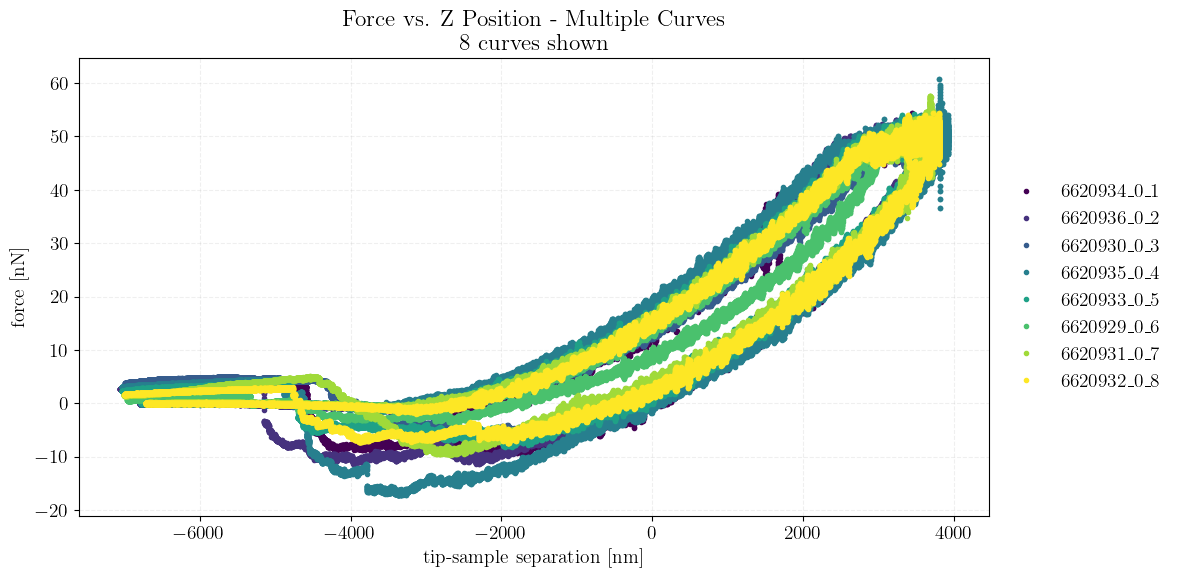

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Force vs. Z Position - Multiple Curves\n8 curves shown'}, xlabel='tip-sample separation [nm]', ylabel='force [nN]'>)

In [19]:
#%matplotlib inline

paths = glob.glob(r"F:\pcameron\3_Experimental\FluidFM\13022025_with_Paula\pause\*.txt")

fluidfm = IndentationSet(paths, exp_type="fluidfm")

fluidfm.plot_all(linestyle="", units="nano")

# Processing data

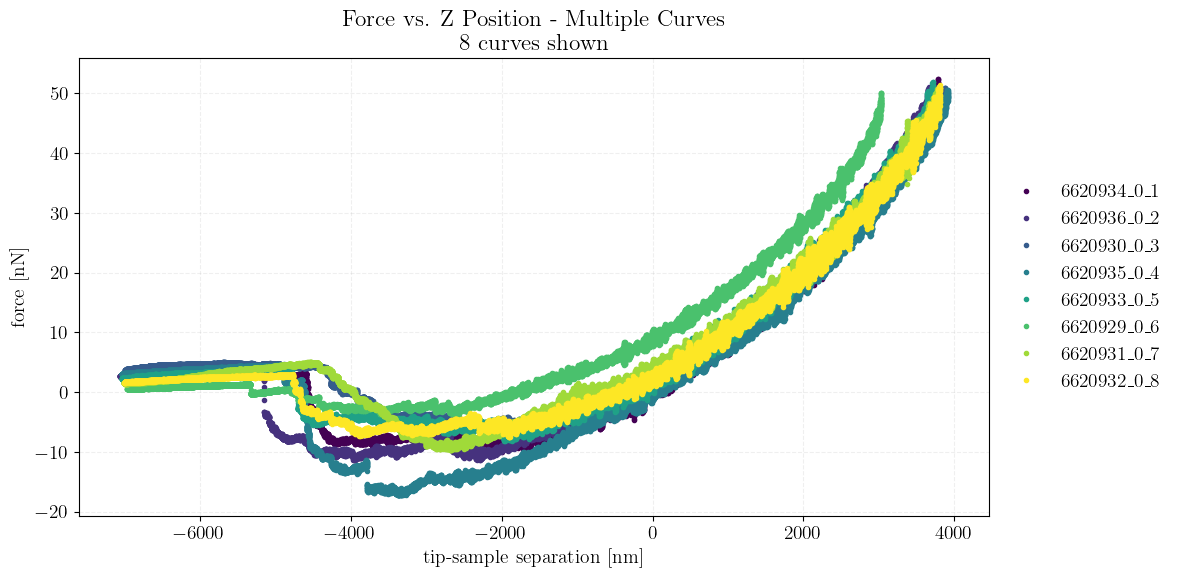

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Force vs. Z Position - Multiple Curves\n8 curves shown'}, xlabel='tip-sample separation [nm]', ylabel='force [nN]'>)

In [20]:
processing_pl = [get_forward_curve, findContact_blackMagic]
processing_pl = [get_retraction_curve]

fluidfm.process_raw(processing_pl)
fluidfm.plot_all(linestyle="", units="nano")

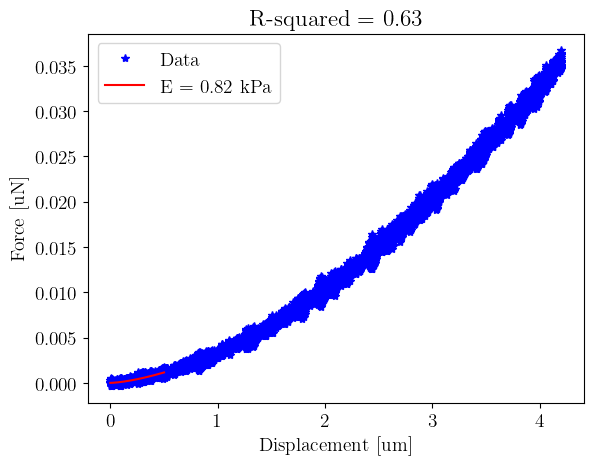

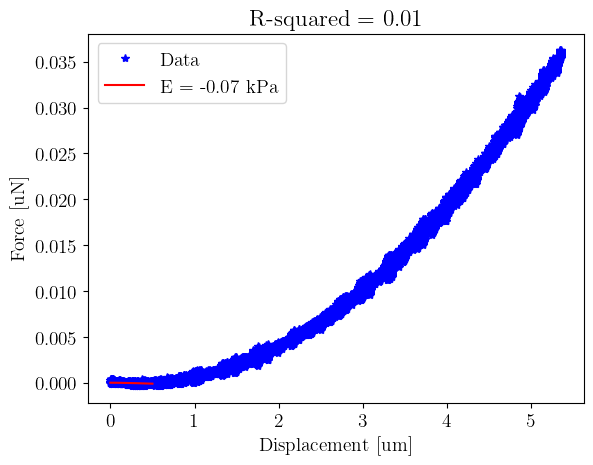

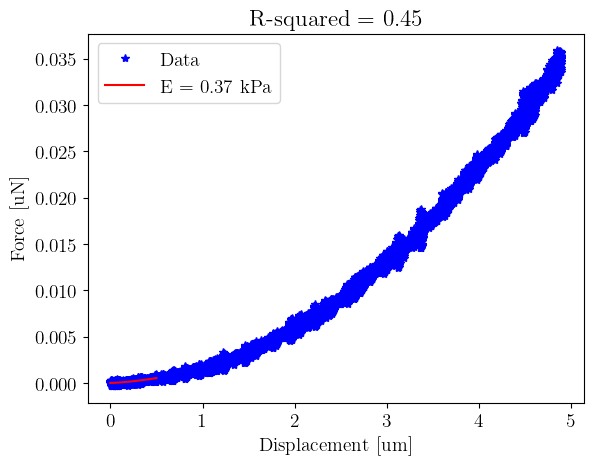

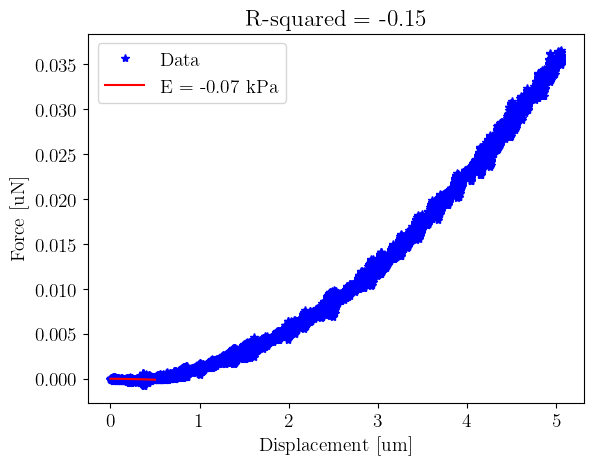

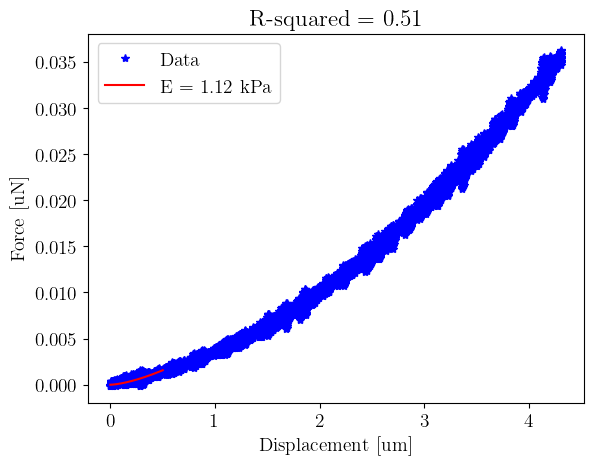

Mean and std: 0.7698933283487955 0.3061897557461747
Number included: 3


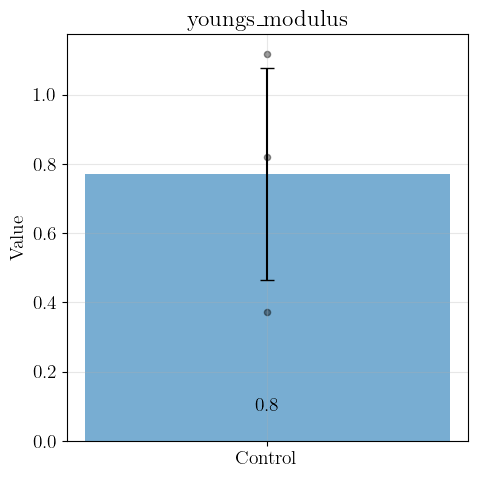

In [6]:
function_arguments = dict(radius=5, nu=0.5, cutoff=10, keyname="youngs_modulus", show_plot=True)
fluidfm.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)
plot_curve_parameters_bar(fluidfm,
                         parameter_names=['youngs_modulus'],
                         labels=['Control'],
                         figsize=(5,5))

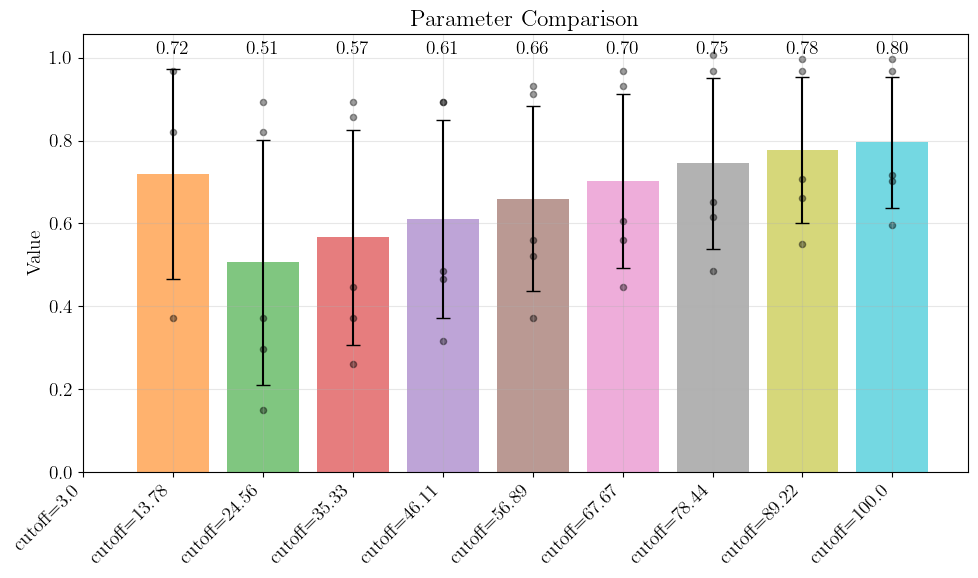

In [7]:
cutoffs = np.linspace(3, 100, 10)

for cutoff in cutoffs:
    function_arguments = dict(radius=5, nu=0.5, cutoff=cutoff, keyname="cutoff="+str(np.round(cutoff, 2)))
    fluidfm.calculate_curve_parameter(function=parameter_youngs_modulus, **function_arguments)

plot_instance_parameters_bar(fluidfm,
                             r_2_thresh=0.5,
                             parameter_names=[*["cutoff="+str(np.round(cutoff, 2)) for cutoff in cutoffs]],
                             figsize=(10,6))